In [1]:
import os
import json
import pickle
import shutil
from datetime import datetime

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Optimizer
import matplotlib.pyplot as plt
import cmath
import math
from math import e
import time
import optuna

from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_contour
# Repro
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1785647380.739804  370161 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785647380.789405  370161 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785647393.849400  370161 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

## **SETTING PARAMETER**

In [4]:
g          = 9.81
n_mann     = 0.0        # Manning = 0 (paper: n=0)
S0         = 0.0        # bed slope = 0 (paper: S0=0)
L          = 200.0      # panjang domain (m)
Ld         = 100.0      # lokasi dam (m)
dx         = 0.65       # spasial numerik (m) sesuai paper
Nx         = int(L / dx) + 1
x_num      = np.linspace(0.0, L, Nx)
hu         = 1.0        # kedalaman upstream (m)
hd         = 0.5        # kedalaman downstream (m)
CFL        = 0.6        # Courant number (paper: Cn=0.6)
t_end      = 15.0       # waktu akhir (s) — paper: T=15s
save_times = [1.0, 5.0, 10.0, 15.0]
dry_tol    = 1e-6


# Domain PINN identik dengan domain numerik
XMIN, XMAX = 0.0, L
TMIN, TMAX = 0.0, t_end

## **OPTIMIZATION METHOD**

### **ADAMW**

In [5]:
# AdamW
class AdamW(Optimizer):
    def __init__(self,
                 learning_rate=0.001, # alpha
                 beta_1=0.9,
                 beta_2=0.999,
                 epsilon=1e-8,
                 weight_decay=0.0,
                 eta_t = None, # Schedule multiplier
                 name="AdamW",**kwargs):
        
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)

        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.epsilon = epsilon
        self.weight_decay = weight_decay

        # eta_t (schedule multiplier)
        if eta_t is None:
            self.eta_t = lambda t: 1.0
        else:
            self.eta_t = eta_t

    def build(self, var_list):
        super().build(var_list)
        # Create slot variables (state)
        self.m = []
        self.v = []

        for var in var_list:
            self.m.append(self.add_variable_from_reference(var, "m"))
            self.v.append(self.add_variable_from_reference(var, "v"))
                
    def update_step(self, grad, var, learning_rate):
        if grad is None:
            return
                
        var_dtype = var.dtype

        lr = tf.cast(learning_rate, var_dtype) # alpha
        beta_1 = tf.cast(self.beta_1, var_dtype)
        beta_2 = tf.cast(self.beta_2, var_dtype)
        epsilon = tf.cast(self.epsilon, var_dtype)
        wd = tf.cast(self.weight_decay, var_dtype)

        index = self._get_variable_index(var)

        m = self.m[index]
        v = self.v[index]

        t = tf.cast(self.iterations + 1, var_dtype)
        eta_t = tf.cast(self.eta_t(self.iterations), var_dtype)

        # Update m and v value
        m.assign(beta_1 * m + (1. - beta_1) * grad)
        v.assign(beta_2 * v + (1. - beta_2) * tf.square(grad))

        # Bias correction
        m_hat = m / (1. - tf.pow(beta_1, t))
        v_hat = v / (1. - tf.pow(beta_2, t))

        # update parameter
        var.assign_sub(eta_t * lr * m_hat / (tf.sqrt(v_hat) + epsilon))

        if self.weight_decay > 0:
            var.assign_sub(eta_t * lr * wd * var)

    def get_config(self):
        return {
            "learning_rate": self.learning_rate,
            "beta_1": self.beta_1,
            "beta_2": self.beta_2,
            "epsilon": self.epsilon,
            "weight_decay": self.weight_decay,
        }

## **LBFGS**

In [6]:
class LBFGS:
    def __init__(self, max_iter=500, m=10, tol=1e-8,
                 c1=1e-4, c2=0.9, max_ls=30, max_zoom=60, ys_min=1e-10,
                 alpha_max=1e4):
        self.max_iter = max_iter   # number of iterations
        self.m = m                 # memory size
        self.tol = tol             # tolerance ||grad||
        self.c1 = c1               # Armijo (sufficient decrease)
        self.c2 = c2               # curvature condition (0.9 for quasi-Newton)
        self.max_ls = max_ls       # max. main phase trial
        self.max_zoom = max_zoom   # max. trial zoom phase
        self.ys_min = ys_min       # additional curvature threshold (safety net)
        self.alpha_max = alpha_max # step size expansion limit

        # --- pembukuan ---
        self.loss_history = []     # ACCEPTED step loss (1 point/iteration)
        self.accept_nfev = []      # position of total nfev when iteration is accepted
        self.nfev_grad = 0         # logged evaluations (loss+gradient), 1 per iteration
        self.nfev_plain = 0        # candidate line search evaluations (loss+gradient)
        self.status = "not_started"
        self.n_iter_done = 0
        self._warned_none_grad = False

    # ---------------- utility ----------------
    @property
    def nfev_total(self):
        return self.nfev_grad + self.nfev_plain

    def pack(self, var_list):
        return tf.concat([tf.reshape(v, [-1]) for v in var_list], axis=0)

    def unpack(self, flat, var_list):
        idx = 0
        for v in var_list:
            size = int(np.prod(v.shape))
            v.assign(tf.reshape(flat[idx:idx + size], v.shape))
            idx += size

    # ---------------- evaluation ----------------
    def _eval(self, var_list, loss_like, counter):
        if counter == "grad":
            self.nfev_grad += 1
        else:
            self.nfev_plain += 1
        with tf.GradientTape() as tape:
            loss = loss_like()
        grads = tape.gradient(loss, var_list)
        if any(g is None for g in grads) and not self._warned_none_grad:
            print("[LBFGS] WARNING: there are None gradients -> possible variable "
                  "disconnected from loss computation (replaced with zeros).")
            self._warned_none_grad = True
        grads = [tf.zeros_like(v) if g is None else g
                 for g, v in zip(grads, var_list)]
        return loss, self.pack(grads)

    def loss_and_grad(self, var_list, loss_fn):
        """logged evaluation: used ONCE per iteration (accepted point)."""
        return self._eval(var_list, loss_fn, counter="grad")

    def _trial_eval(self, theta, p, alpha, var_list, loss_plain):
        """Evaluate line search candidate (without logging)."""
        self.unpack(theta + alpha * p, var_list)
        loss, grad = self._eval(var_list, loss_plain, counter="plain")
        return float(loss), grad, float(tf.tensordot(grad, p, axes=1))

    # ---------------- two-loop recursion ----------------
    def two_loop(self, grad, s_list, y_list):
        q = tf.identity(grad)
        alpha = []
        for i in reversed(range(len(s_list))):
            s, y = s_list[i], y_list[i]
            rho = 1.0 / tf.tensordot(y, s, axes=1)
            a = rho * tf.tensordot(s, q, axes=1)
            alpha.append(a)
            q = q - a * y
        if len(s_list) > 0:      # H0 = gamma * I
            s_last, y_last = s_list[-1], y_list[-1]
            gamma = (tf.tensordot(s_last, y_last, axes=1)
                     / tf.tensordot(y_last, y_last, axes=1))
        else:
            gamma = 1.0
        r = gamma * q
        for i in range(len(s_list)):
            s, y = s_list[i], y_list[i]
            rho = 1.0 / tf.tensordot(y, s, axes=1)
            b = rho * tf.tensordot(y, r, axes=1)
            r = r + s * (alpha[len(s_list) - 1 - i] - b)
        return -r

    # ---------------- strong Wolfe line search ----------------
    def line_search(self, theta, p, loss_val, gTp, var_list, loss_plain):
        """Return (alpha, ok). gTp < 0 must be guaranteed by the caller.
        Implementation of Alg. 3.5: main phase with alpha expansion up to alpha_max,
        each failure enters the zoom phase."""
        phi0, dphi0 = loss_val, gTp
        a_prev, phi_prev = 0.0, phi0
        a = 1.0                      
        for i in range(self.max_ls):
            phi, _, dphi = self._trial_eval(theta, p, a, var_list, loss_plain)

            # non-finite (NaN/Inf) considered as Armijo failure -> narrow bracket
            armijo_ok = math.isfinite(phi) and (phi <= phi0 + self.c1 * a * dphi0)
            if (not armijo_ok) or (i > 0 and phi >= phi_prev):
                return self._zoom(theta, p, phi0, dphi0, var_list, loss_plain,
                                  a_prev, phi_prev, None, a, phi)
            if abs(dphi) <= -self.c2 * dphi0:
                return a, True
            if dphi >= 0:
                return self._zoom(theta, p, phi0, dphi0, var_list, loss_plain,
                                  a, phi, dphi, a_prev, phi_prev)
            # curvature is not sufficient & still decreasing -> EXPANSION (not a failure)
            a_prev, phi_prev = a, phi
            a = min(2.0 * a, self.alpha_max)
            if a >= self.alpha_max:
                break
        self.unpack(theta, var_list)         # ensure clean state
        return 0.0, False

    def _zoom(self, theta, p, phi0, dphi0, var_list, loss_plain,
              lo, lo_phi, lo_dphi, hi, hi_phi):
        for _ in range(self.max_zoom):
            span = hi - lo
            if abs(span) < 1e-16:
                return 0.0, False
            # numerical quadratic interpolation from phi(lo), phi(hi), phi'(lo) if available
            a_j = None
            if lo_dphi is not None:
                denom = 2.0 * (hi_phi - lo_phi - lo_dphi * span)
                if denom != 0.0 and math.isfinite(denom):
                    cand = lo - lo_dphi * span**2 / denom
                    if min(lo, hi) < cand < max(lo, hi) and math.isfinite(cand):
                        a_j = cand
            if a_j is None:
                a_j = 0.5 * (lo + hi)

            phi_j, _, dphi_j = self._trial_eval(theta, p, a_j, var_list, loss_plain)

            fail_hi = ((not math.isfinite(phi_j))
                       or phi_j > phi0 + self.c1 * a_j * dphi0
                       or phi_j >= lo_phi)
            if fail_hi:
                hi, hi_phi = a_j, phi_j
            else:
                if abs(dphi_j) <= -self.c2 * dphi0:
                    return a_j, True
                if dphi_j * (hi - lo) >= 0:
                    hi, hi_phi = lo, lo_phi
                lo, lo_phi, lo_dphi = a_j, phi_j, dphi_j
        return 0.0, False

    # ---------------- main loop ----------------
    def minimize(self, var_list, loss_fn, loss_plain=None):
        """
        loss_fn    : callable -> scalar loss; dievaluasi logged SEKALI per iterasi
                     (boleh berisi log_history/counter).
        loss_plain : callable -> scalar loss TANPA logging/counter; dipakai
                     untuk semua kandidat line search. WAJIB utk kurva bersih.
        """
        if loss_plain is None:
            print("[LBFGS] WARNING: loss_plain is not provided -> line search candidates "
                  "will be logged if loss_fn contains logging.")
            loss_plain = loss_fn

        theta = self.pack(var_list)
        s_list, y_list = [], []
        self.loss_history, self.accept_nfev = [], []

        loss, grad = self.loss_and_grad(var_list, loss_fn)

        for k in range(self.max_iter):
            gnorm = float(tf.norm(grad))
            if gnorm < self.tol:
                self.status = f"converged (||grad||={gnorm:.2e} < tol)"
                print(f"[LBFGS] {self.status} on iteration {k}")
                break

            p = self.two_loop(grad, s_list, y_list)

            # descent direction guardian + memory reset
            gTp = float(tf.tensordot(grad, p, axes=1))
            if (not math.isfinite(gTp)) or gTp >= 0.0:
                p = -grad
                gTp = -float(tf.tensordot(grad, grad, axes=1))
                s_list, y_list = [], []

            alpha, ok = self.line_search(theta, p, float(loss), gTp,
                                         var_list, loss_plain)
            if not ok:
                self.status = (f"line search failed to satisfy strong Wolfe "
                               f"on iteration {k} (consider float64)")
                print(f"[LBFGS] {self.status}")
                self.unpack(theta, var_list)   # ensure clean state
                break

            theta_old = theta
            theta = theta + alpha * p
            self.unpack(theta, var_list)
            loss_new, grad_new = self.loss_and_grad(var_list, loss_fn)
            self.loss_history.append(float(loss_new))
            self.accept_nfev.append(self.nfev_total)

            s = theta - theta_old
            y = grad_new - grad
            ys = float(tf.tensordot(y, s, axes=1))
            if math.isfinite(ys) and ys > self.ys_min:
                s_list.append(s)
                y_list.append(y)
                if len(s_list) > self.m:
                    s_list.pop(0)
                    y_list.pop(0)

            loss, grad = loss_new, grad_new
            self.n_iter_done = k + 1

            if k % 10 == 0:
                print(f"[LBFGS] iter {k:4d} | loss {float(loss_new):.3e} | "
                      f"alpha {alpha:.2e} | ||g|| {gnorm:.3e} | m={len(s_list)}")
        else:
            self.status = "max_iter tercapai"

        print(f"[LBFGS] finished: status='{self.status}', iteration={self.n_iter_done}, "
              f"NFe(grad)={self.nfev_grad}, NFe(plain)={self.nfev_plain}, "
              f"NFe(total)={self.nfev_total}")
        return theta

## **SOLUSI NUMERIK**

In [7]:
def manning_friction_slope(h, u, n=n_mann):
    Sf  = np.zeros_like(h)
    wet = h > dry_tol
    if n > 0:
        Sf[wet] = (u[wet]**2)*(n**2) / np.maximum(h[wet], dry_tol)**(4./3.)
    return Sf
 
# Batas kecepatan fisik: 10 × celerity gelombang upstream
U_MAX = 10. * np.sqrt(g * hu)   # ≈ 31 m/s
 
def compute_dt(h, u, dx_val, CFL_val):
    c    = np.sqrt(g * np.maximum(h, dry_tol))
    # clip u sebelum hitung vmax agar dt tidak collapse ke 0
    vmax = np.max(np.minimum(np.abs(u), U_MAX) + c)
    if vmax < 1e-12:
        return 1e-3
    return CFL_val * dx_val / vmax
 
def clip_u(u):
    """Clip kecepatan ke batas fisik agar tidak blow-up di wavefront."""
    return np.clip(u, -U_MAX, U_MAX)
 
def safe_d1(f, wet):
    """Central diff ke-1 — nol di dry cell."""
    fs = np.where(wet, f, 0.0); df = np.zeros_like(fs)
    df[1:-1] = (fs[2:] - fs[:-2]) / (2.*dx)
    return np.where(wet, df, 0.0)
 
def safe_d2(f, wet):
    """Central diff ke-2 — nol di dry cell."""
    fs = np.where(wet, f, 0.0); d2 = np.zeros_like(fs)
    d2[1:-1] = (fs[2:] - 2.*fs[1:-1] + fs[:-2]) / (dx**2)
    return np.where(wet, d2, 0.0)
 
def bous_mask(wet):
    """
    Sel yang boleh pakai suku Boussinesq:
    harus wet DAN semua tetangganya juga wet.
    Di wavefront (ada tetangga dry) → SWE murni.
    """
    m = wet.copy()
    m[1:-1] = wet[1:-1] & wet[:-2] & wet[2:]
    m[0] = False; m[-1] = False
    return m
 
def compute_T(h, u):
    """T = u²h + gh²/2 + B2 + B3; Boussinesq=0 di wavefront & dry cell."""
    wet = h > dry_tol; bm = bous_mask(wet)
    u_s = np.where(wet, u, 0.0)
    du  = safe_d1(u_s, wet); d2u = safe_d2(u_s, wet)
    h3  = np.where(bm, h**3, 0.0)
    B2  = np.where(bm, -(h3/3.)*u_s*d2u, 0.0)
    B3  = np.where(bm,  (h3/3.)*(du**2),  0.0)
    return u_s**2*h + 0.5*g*h**2 + B2 + B3
 
def art_visc(h, u, kappa=0.5):
    """Artificial viscosity sesuai paper [24], kappa=0.5."""
    hn = h.copy(); un = u.copy()
    hn[1:-1] += kappa*0.25*(h[2:] - 2.*h[1:-1] + h[:-2])
    un[1:-1] += kappa*0.25*(u[2:] - 2.*u[1:-1] + u[:-2])
    return hn, un
 
 
def predictor_step(h, u, dt, dx_val):
    wet    = h > dry_tol
    u_s    = np.where(wet, clip_u(u), 0.0)
    q      = h * u_s; T = compute_T(h, u_s)
    Sf     = manning_friction_slope(h, u_s)
    hp     = h.copy(); up = np.zeros_like(u)
    hp[:-1] = h[:-1] + (dt/dx_val)*(q[:-1] - q[1:])
    hp      = np.maximum(hp, dry_tol)
    rhs     = q[:-1] + (dt/dx_val)*(T[:-1]-T[1:]) + dt*g*h[:-1]*(S0-Sf[:-1])
    up[:-1] = np.where(wet[:-1]|wet[1:], rhs/np.maximum(hp[:-1],dry_tol), 0.0)
    up      = clip_u(up)
    up[0]   = 0.; up[-1]  = 0.
    hp[0]   = hp[1]; hp[-1] = hp[-2]
    return hp, up
 
def corrector_step(hp, up, dt, dx_val):
    wet_p  = hp > dry_tol
    up_s   = np.where(wet_p, clip_u(up), 0.0)
    qp     = hp * up_s; Tp = compute_T(hp, up_s)
    Sf     = manning_friction_slope(hp, up_s)
    hc     = hp.copy(); uc = np.zeros_like(up)
    hc[1:] = hp[1:] + (dt/dx_val)*(-qp[1:] + qp[:-1])
    hc     = np.maximum(hc, dry_tol)
    rhs    = qp[1:] + (dt/dx_val)*(-Tp[1:]+Tp[:-1]) + dt*g*hp[1:]*(S0-Sf[1:])
    uc[1:] = np.where(wet_p[:-1]|wet_p[1:], rhs/np.maximum(hc[1:],dry_tol), 0.0)
    uc     = clip_u(uc)
    uc[0]  = 0.; uc[-1]  = 0.
    hc[0]  = hc[1]; hc[-1] = hc[-2]
    return hc, uc
 
def final_b1_correction(uk, hbar, ubar, dt, dx_val):
    """
    B1 correction hanya di interior wet (semua tetangga wet).
    Di wavefront dilewati untuk mencegah blow-up saat h→0.
    """
    wet  = hbar > dry_tol; bm = bous_mask(wet)
    uk_s = np.where(wet, uk,   0.0)
    ub_s = np.where(wet, ubar, 0.0)
    B1   = np.zeros_like(ubar)
    B1[1:-1] = np.where(bm[1:-1],
        -(hbar[1:-1]**3 / (6.*dx_val*dt)) * (
            (ub_s[2:] - ub_s[:-2]) - (uk_s[2:] - uk_s[:-2])),
        0.0)
    dB1dx = np.zeros_like(B1)
    dB1dx[1:-1] = (B1[2:] - B1[:-2]) / (2.*dx_val)
    unew  = np.where(wet, ub_s-(dt/np.maximum(hbar,dry_tol))*dB1dx, 0.0)
    unew  = clip_u(unew)
    unew[0] = 0.; unew[-1] = 0.
    return unew
 
def solve_modified_mc(h_init, u_init, t_final, save_times):
    """Solver Modified MC wet-dry — return dict {t: (h_array, u_array)}"""
    h     = h_init.copy()
    u     = u_init.copy()
    kappa = 0.5
    t     = 0.0
    out   = {}
    saved = set()
    while t < t_final - 1e-10:
        dt     = min(compute_dt(h, u, dx, CFL), t_final - t)
        hp, up = predictor_step(h, u, dt, dx)
        hc, uc = corrector_step(hp, up, dt, dx)
        hbar   = np.maximum(0.5*(h + hc), dry_tol)
        ubar   = np.where(hbar > dry_tol, 0.5*(u + uc), 0.0)
        h      = hbar.copy()
        u      = final_b1_correction(u, hbar, ubar, dt, dx)
        # artificial viscosity (paper Section 3.1)
        h, u   = art_visc(h, u, kappa)
        h      = np.maximum(h, dry_tol)
        u      = np.where(h > dry_tol, u, 0.0)
        t     += dt
        for ts in save_times:
            if ts not in saved and abs(t - ts) <= dt + 1e-10:
                out[ts] = (h.copy(), u.copy())
                saved.add(ts)
    return out

In [8]:
# Initial Condition
# WetDry Dam Break h0
h0_num   = np.where(x_num <= Ld, hu, 0.0).astype(np.float64)
u0_num   = np.zeros_like(x_num)
 
# IC PINN — dry zone = dry_tol (bukan persis 0)
h0_ic_np = np.where(x_num <= Ld, hu, dry_tol).astype(np.float32)
u0_ic_np = u0_num.astype(np.float32)
 
x_ic_tf  = tf.constant(x_num.reshape(-1,1).astype(np.float32))
h0_ic_tf = tf.constant(h0_ic_np.reshape(-1,1))
u0_ic_tf = tf.constant(u0_ic_np.reshape(-1,1))

I0000 00:00:1785647405.611375  370161 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21452 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


In [9]:
# Penyelesaian Numerik
t_s        = time.perf_counter()
results_mc = solve_modified_mc(h0_num, u0_num, t_end, save_times)
t_e        = time.perf_counter()
print(f"  Selesai dalam {t_e-t_s:.3f} s")
print(f"  Tersimpan pada t = {list(results_mc.keys())} s\n")

  Selesai dalam 0.020 s
  Tersimpan pada t = [1.0, 5.0, 10.0, 15.0] s



In [10]:
# Data Latih PINN dari Solusi Numerik
x_all_lst, t_all_lst, h_all_lst, u_all_lst = [], [], [], []
for ts in save_times:
    if ts not in results_mc:
        continue
    h_ts, u_ts = results_mc[ts]
    x_all_lst.append(x_num)
    t_all_lst.append(np.full(Nx, ts))
    h_all_lst.append(h_ts)
    u_all_lst.append(u_ts)
 
x_all = np.concatenate(x_all_lst).astype(np.float32)
t_all = np.concatenate(t_all_lst).astype(np.float32)
h_all = np.concatenate(h_all_lst).astype(np.float32)
u_all = np.concatenate(u_all_lst).astype(np.float32)
 
# Subsample 15% acak
N_total   = len(x_all)
idx       = np.random.choice(N_total, size=int(0.15*N_total), replace=False)
x_data_tf = tf.constant(x_all[idx].reshape(-1,1))
t_data_tf = tf.constant(t_all[idx].reshape(-1,1))
h_data_tf = tf.constant(h_all[idx].reshape(-1,1))
u_data_tf = tf.constant(u_all[idx].reshape(-1,1))
 
print(f"  Data numerik: {N_total} titik  subsample {len(idx)} (15%)\n")

  Data numerik: 1232 titik  subsample 184 (15%)



## **SOLUSI PINN - OPTIMISASI BAYESIAN**

In [11]:
# Collocotion Point
NT_col, NX_col = 150, 150
t_grid   = np.linspace(TMIN, TMAX, NT_col, dtype=np.float32)
x_grid   = np.linspace(XMIN, XMAX, NX_col, dtype=np.float32)
TT, XX   = np.meshgrid(t_grid, x_grid, indexing='ij')
x_col_tf = tf.constant(XX.reshape(-1,1))
t_col_tf = tf.constant(TT.reshape(-1,1))

In [10]:
# Output folders
OPTUNA_DIR = r"/mnt/d/PINN Research_Iwan/CodeBaru/best_models"
BEST_DIR = os.path.join(OPTUNA_DIR, "best_BO_wetdry_AdamW_AdamW")

os.makedirs(OPTUNA_DIR, exist_ok=True)

fig_dir = r"/mnt/d/PINN Research_Iwan/CodeBaru/figures"
os.makedirs(fig_dir, exist_ok=True)

best_loss_global = np.inf

In [13]:
# Neural Network
def build_mlp(trial, name="nn_core"):
    n_layers = trial.suggest_int("n_layers", 3, 5)
    activation = trial.suggest_categorical("activation", ["tanh", "swish"])
    
    inputs = layers.Input(shape=(2,))
    z = inputs
    widths = []
    for i in range(n_layers):
        units = trial.suggest_int(f"units_layer_{i}", 32, 128)
        widths.append(units)
        z = layers.Dense(units, activation=activation, kernel_initializer="glorot_normal")(z)
    out = layers.Dense(1, activation="linear")(z)
    return Model(inputs, out, name="nn_core")

In [14]:
# Loss Function
# @tf.function
def pde_loss(x, t):
    """
    Residu persamaan Boussinesq 1D (paper eq. 1-3)
    n=0, S0=0, Sf=0 sesuai paper Section 4.1
    """
    with tf.GradientTape(persistent=True) as tape3:
        tape3.watch([x, t])
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch([x, t])
            with tf.GradientTape(persistent=True) as tape1:
                tape1.watch([x, t])
                X    = tf.concat([x, t], axis=1)
                h    = h_model(X)
                u    = u_model(X)
                h2   = h**2
                h3   = h**3
                uh   = u * h
                u2h  = (u**2) * h
            u_x   = tape1.gradient(u,   x)
            u_t   = tape1.gradient(u,   t)
            h_t   = tape1.gradient(h,   t)
            uh_x  = tape1.gradient(uh,  x)
            uh_t  = tape1.gradient(uh,  t)
            h2_x  = tape1.gradient(h2,  x)
            h3_x  = tape1.gradient(h3,  x)
            u2h_x = tape1.gradient(u2h, x)
            del tape1
        u_xx  = tape2.gradient(u_x, x)
        u_xt  = tape2.gradient(u_x, t)
        del tape2
    u_xxx = tape3.gradient(u_xx, x)
    u_xxt = tape3.gradient(u_xx, t)
    del tape3
 
    # Boussinesq terms divergence form (paper eq. 3)
    B1_x = (-h3_x/3.)*u_xt  - (h3/3.)*u_xxt
    B2_x = (-h3_x/3.)*u*u_xx - (h3/3.)*u_x*u_xx - (h3/3.)*u*u_xxx
    B3_x = (h3_x/3.)*(u_x**2) + (2.*h3/3.)*u_x*u_xx
 
    R1 = h_t + uh_x
    R2 = uh_t + u2h_x + (g/2.)*h2_x + B1_x + B2_x + B3_x
    # gh(S0-Sf)=0 karena n=0, S0=0
 
    return tf.reduce_mean(R1**2 + R2**2)
 
 
def ic_loss():
    """
    IC sesuai paper — identik dengan kondisi awal numerik
      h(x,0) = hu jika x<=Ld, hd jika x>Ld
      u(x,0) = 0
    """
    t0     = tf.zeros((Nx, 1), dtype=tf.float32)
    X_ic   = tf.concat([x_ic_tf, t0], axis=1)
    h_pred = h_model(X_ic)
    u_pred = u_model(X_ic)
    return (tf.reduce_mean((h_pred - h0_ic_tf)**2) +
            tf.reduce_mean((u_pred - u0_ic_tf)**2))
 
 
# @tf.function
def bc_loss(n_pts=100):
    """
    BC sesuai paper:
      Dirichlet u : u(0,t)=0, u(L,t)=0       (wall BC)
      Neumann h   : dh/dx(0,t)=0, dh/dx(L,t)=0  (zero-gradient)
                    setara hp[0]=hp[1], hp[-1]=hp[-2] di numerik
    """
    t_bc    = tf.random.uniform((n_pts, 1), TMIN, TMAX)
    x_left  = tf.zeros((n_pts, 1), dtype=tf.float32)
    x_right = tf.fill((n_pts, 1), tf.cast(L, tf.float32))
 
    # Dirichlet u=0
    u_left  = u_model(tf.concat([x_left,  t_bc], axis=1))
    u_right = u_model(tf.concat([x_right, t_bc], axis=1))
    loss_u  = tf.reduce_mean(u_left**2) + tf.reduce_mean(u_right**2)
 
    # Neumann dh/dx=0
    with tf.GradientTape(persistent=True) as tape_bc:
        tape_bc.watch([x_left, x_right])
        h_left  = h_model(tf.concat([x_left,  t_bc], axis=1))
        h_right = h_model(tf.concat([x_right, t_bc], axis=1))
    dh_left  = tape_bc.gradient(h_left,  x_left)
    dh_right = tape_bc.gradient(h_right, x_right)
    del tape_bc
    loss_h   = tf.reduce_mean(dh_left**2) + tf.reduce_mean(dh_right**2)
 
    return loss_u + loss_h
 
 
def data_loss_fn():
    """MSE antara prediksi PINN dan data numerik Modified MC."""
    X_d    = tf.concat([x_data_tf, t_data_tf], axis=1)
    h_pred = h_model(X_d)
    u_pred = u_model(X_d)
    return (tf.reduce_mean((h_pred - h_data_tf)**2) +
            tf.reduce_mean((u_pred - u_data_tf)**2))
 
 
def total_loss(lambda_pde=1.0, lambda_ic=10.0,
               lambda_bc=5.0,  lambda_data=0.5):
    lp   = pde_loss(x_col_tf, t_col_tf)
    lic  = ic_loss()
    lbc  = bc_loss()
    ldat = data_loss_fn()
    tot  = lambda_pde*lp + lambda_ic*lic + lambda_bc*lbc + lambda_data*ldat
    return tot, lp, lic, lbc, ldat

## **TRAIN PINN**

In [15]:
# Objective function for Optuna
def objective(trial):
    global h_model, u_model
    global best_loss_global

    tf.keras.backend.clear_session()

    # ============================================================
    # Build models
    # ============================================================
    h_model = build_mlp(trial, name="h_model")
    u_model = build_mlp(trial, name="u_model")

    dummy = tf.zeros((1, 2), dtype=tf.float32)
    _ = h_model(dummy)
    _ = u_model(dummy)

    vars_list = h_model.trainable_variables + u_model.trainable_variables

    # ============================================================
    # History
    # ============================================================
    history = {
        k: [] for k in [
            "step",
            "total",
            "pde",
            "ic",
            "bc",
            "data",
            "phase"
        ]
    }

    def to_float(x):
        return float(x.numpy() if hasattr(x, "numpy") else x)

    def log_history(vals, step, phase):
        keys = ["total", "pde", "ic", "bc", "data"]

        history["step"].append(step)

        for k, v in zip(keys, vals):
            history[k].append(to_float(v))

        history["phase"].append(phase)

    # ============================================================
    # Hyperparameters
    # ============================================================
    lr1 = trial.suggest_float("lr_phase1", 1e-4, 1e-2, log=True)
    lr2 = trial.suggest_float("lr_phase2", 1e-5, 1e-3, log=True)

    wd1 = trial.suggest_float("weight_decay_phase1", 1e-6, 1e-3, log=True)
    wd2 = trial.suggest_float("weight_decay_phase2", 1e-7, 1e-4, log=True)

    epochs1 = 1000
    epochs2 = 500

    opt1 = AdamW(
        learning_rate=lr1,
        weight_decay=wd1
    )

    opt2 = AdamW(
        learning_rate=lr2,
        weight_decay=wd2
    )

    t0_train = time.perf_counter()

    # ============================================================
    # Phase 1: AdamW pretraining
    # ============================================================
    for epoch in range(1, epochs1 + 1):
        with tf.GradientTape() as tape:
            loss, lp, lic, lbc, ldat = total_loss()

        grads = tape.gradient(loss, vars_list)
        opt1.apply_gradients(zip(grads, vars_list))

        global_step = epoch

        log_history(
            [loss, lp, lic, lbc, ldat],
            step=global_step,
            phase="AdamW-1"
        )

        if epoch % 200 == 0:
            trial.report(float(loss.numpy()), step=global_step)

            if trial.should_prune():
                raise optuna.TrialPruned()

    # ============================================================
    # Phase 2: AdamW fine-tuning
    # ============================================================
    for epoch in range(1, epochs2 + 1):
        with tf.GradientTape() as tape:
            loss, lp, lic, lbc, ldat = total_loss()

        grads = tape.gradient(loss, vars_list)
        opt2.apply_gradients(zip(grads, vars_list))

        global_step = epochs1 + epoch

        log_history(
            [loss, lp, lic, lbc, ldat],
            step=global_step,
            phase="AdamW-2"
        )

        if epoch % 200 == 0:
            trial.report(float(loss.numpy()), step=global_step)

            if trial.should_prune():
                raise optuna.TrialPruned()

    # ============================================================
    # Final evaluation
    # ============================================================
    # Penting:
    # Hitung ulang loss setelah update terakhir opt2.
    # Kalau tidak, final_loss berasal dari loss sebelum update terakhir.
    loss, lp, lic, lbc, ldat = total_loss()

    final_step = epochs1 + epochs2 + 1

    log_history(
        [loss, lp, lic, lbc, ldat],
        step=final_step,
        phase="Final"
    )

    t1_train = time.perf_counter()
    final_loss = float(loss.numpy())

    # ============================================================
    # Save trial attributes
    # ============================================================
    trial.set_user_attr("final_loss", final_loss)
    trial.set_user_attr("final_pde", float(lp.numpy()))
    trial.set_user_attr("final_ic", float(lic.numpy()))
    trial.set_user_attr("final_bc", float(lbc.numpy()))
    trial.set_user_attr("final_data", float(ldat.numpy()))
    trial.set_user_attr("training_time", float(t1_train - t0_train))

    trial.set_user_attr("epochs_phase1", epochs1)
    trial.set_user_attr("epochs_phase2", epochs2)

    # ============================================================
    # Save best model
    # ============================================================
    if final_loss < best_loss_global:
        best_loss_global = final_loss

        if os.path.exists(BEST_DIR):
            shutil.rmtree(BEST_DIR)

        os.makedirs(BEST_DIR, exist_ok=True)

        h_model.save(os.path.join(BEST_DIR, "h_model.keras"))
        u_model.save(os.path.join(BEST_DIR, "u_model.keras"))

        with open(os.path.join(BEST_DIR, "best_params.json"), "w") as f:
            json.dump(trial.params, f, indent=4)

        with open(os.path.join(BEST_DIR, "best_history.pkl"), "wb") as f:
            pickle.dump(history, f)

        print(
            f"\n*** New best model saved | "
            f"Trial {trial.number} | Loss={final_loss:.3e} ***\n"
        )

    return final_loss

In [ ]:
# Run Optuna study
study = optuna.create_study(
    study_name="Bayesian Optimization PINN - WetDry",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.NopPruner()
)

study.optimize(objective, n_trials=30)


EXP_NAME = "BO_WetDry_AdamAdam"   
# EXP_NAME = "BO_Undular_AdamLBFGS"

# Folder penyimpanan
STUDY_DIR = os.path.join(OPTUNA_DIR, "Study")
TRIAL_DIR = os.path.join(OPTUNA_DIR, "Trial")

# Save study and trial history
with open(os.path.join(STUDY_DIR, f"study_{EXP_NAME}.pkl"), "wb") as f:
    pickle.dump(study, f)

df_trials = study.trials_dataframe()
df_trials.to_csv(os.path.join(TRIAL_DIR, f"trial_history_{EXP_NAME}.csv"), index=False)

# Print result
print("=" * 58)
print("Optuna optimization finished")
print("=" * 58)
print("Best trial:", study.best_trial.number)
print("Best value:", study.best_value)
print("Best params:", study.best_params)
print(f"Best model saved in: {BEST_DIR}")

[I 2026-07-05 06:19:25,810] A new study created in memory with name: Bayesian Optimization PINN - WetDry
[I 2026-07-05 06:23:55,068] Trial 0 finished with value: 0.17881619930267334 and parameters: {'n_layers': 4, 'activation': 'tanh', 'units_layer_0': 90, 'units_layer_1': 47, 'units_layer_2': 47, 'units_layer_3': 37, 'lr_phase1': 0.005399484409787433, 'lr_phase2': 0.00015930522616241006, 'weight_decay_phase1': 0.000133112160807369, 'weight_decay_phase2': 1.152798712823239e-07}. Best is trial 0 with value: 0.17881619930267334.



*** New best model saved | Trial 0 | Loss=1.788e-01 ***



[I 2026-07-05 06:29:18,611] Trial 1 finished with value: 0.27602335810661316 and parameters: {'n_layers': 5, 'activation': 'tanh', 'units_layer_0': 49, 'units_layer_1': 49, 'units_layer_2': 61, 'units_layer_3': 82, 'units_layer_4': 73, 'lr_phase1': 0.0003823475224675188, 'lr_phase2': 0.00016738085788752134, 'weight_decay_phase1': 2.62108787826544e-06, 'weight_decay_phase2': 7.52374288453486e-07}. Best is trial 0 with value: 0.17881619930267334.
[I 2026-07-05 06:39:28,918] Trial 2 finished with value: 0.2599617540836334 and parameters: {'n_layers': 4, 'activation': 'swish', 'units_layer_0': 51, 'units_layer_1': 81, 'units_layer_2': 89, 'units_layer_3': 36, 'lr_phase1': 0.0016409286730647919, 'lr_phase2': 2.1930485556643678e-05, 'weight_decay_phase1': 1.5673095467235414e-06, 'weight_decay_phase2': 7.025166339242167e-05}. Best is trial 0 with value: 0.17881619930267334.
[I 2026-07-05 06:44:57,591] Trial 3 finished with value: 0.3177793622016907 and parameters: {'n_layers': 5, 'activation'


*** New best model saved | Trial 8 | Loss=1.509e-01 ***



[I 2026-07-05 07:23:29,547] Trial 9 finished with value: 0.2666683793067932 and parameters: {'n_layers': 3, 'activation': 'tanh', 'units_layer_0': 81, 'units_layer_1': 120, 'units_layer_2': 56, 'lr_phase1': 0.000661859559718348, 'lr_phase2': 0.0003244160088734161, 'weight_decay_phase1': 4.857295179217169e-06, 'weight_decay_phase2': 1.7019223026554018e-07}. Best is trial 8 with value: 0.1509181410074234.
[I 2026-07-05 07:39:14,208] Trial 10 finished with value: 0.097468301653862 and parameters: {'n_layers': 4, 'activation': 'swish', 'units_layer_0': 126, 'units_layer_1': 33, 'units_layer_2': 125, 'units_layer_3': 120, 'lr_phase1': 0.001640148320264183, 'lr_phase2': 1.1011690699342257e-05, 'weight_decay_phase1': 0.0006932432173673802, 'weight_decay_phase2': 1.376615737978465e-06}. Best is trial 10 with value: 0.097468301653862.



*** New best model saved | Trial 10 | Loss=9.747e-02 ***



[I 2026-07-05 07:49:32,744] Trial 11 finished with value: 0.14748278260231018 and parameters: {'n_layers': 4, 'activation': 'swish', 'units_layer_0': 126, 'units_layer_1': 38, 'units_layer_2': 127, 'units_layer_3': 125, 'lr_phase1': 0.0016382061352101032, 'lr_phase2': 1.0320310595260912e-05, 'weight_decay_phase1': 0.0005413215439372608, 'weight_decay_phase2': 6.97918600627263e-07}. Best is trial 10 with value: 0.097468301653862.
[I 2026-07-05 07:59:46,348] Trial 12 finished with value: 0.11643312871456146 and parameters: {'n_layers': 4, 'activation': 'swish', 'units_layer_0': 128, 'units_layer_1': 34, 'units_layer_2': 128, 'units_layer_3': 128, 'lr_phase1': 0.0025694303726499193, 'lr_phase2': 1.0462338269644083e-05, 'weight_decay_phase1': 0.0009242967416322827, 'weight_decay_phase2': 8.840803807937691e-07}. Best is trial 10 with value: 0.097468301653862.
[I 2026-07-05 08:09:59,460] Trial 13 finished with value: 0.17352542281150818 and parameters: {'n_layers': 4, 'activation': 'swish', 

Optuna optimization finished
Best trial: 10
Best value: 0.097468301653862
Best params: {'n_layers': 4, 'activation': 'swish', 'units_layer_0': 126, 'units_layer_1': 33, 'units_layer_2': 125, 'units_layer_3': 120, 'lr_phase1': 0.001640148320264183, 'lr_phase2': 1.1011690699342257e-05, 'weight_decay_phase1': 0.0006932432173673802, 'weight_decay_phase2': 1.376615737978465e-06}
Best model saved in: /mnt/d/PINN Research_Iwan/CodeBaru/best_models/best_BO_wetdry_AdamW_AdamW


In [17]:
plot_optimization_history(study)

In [18]:
plot_contour(study)

In [19]:
plot_param_importances(study)

In [11]:
# Load best model
h_model = tf.keras.models.load_model(os.path.join(BEST_DIR, "h_model.keras"))
u_model = tf.keras.models.load_model(os.path.join(BEST_DIR, "u_model.keras"))

with open(os.path.join(BEST_DIR, "best_params.json"), "r") as f:
    best_params = json.load(f)

with open(os.path.join(BEST_DIR, "best_history.pkl"), "rb") as f:
    best_history = pickle.load(f)

In [14]:
# Evaluasi RMSE
for ts in save_times:
    if ts not in results_mc:
        continue
    h_mc_ts, u_mc_ts = results_mc[ts]
    X_ts = tf.constant(
        np.stack([x_num.astype(np.float32),
                  np.full(Nx, ts, dtype=np.float32)], axis=1))
    h_p    = h_model(X_ts).numpy().flatten()
    u_p    = u_model(X_ts).numpy().flatten()
    rmse_h = np.sqrt(np.mean((h_p - h_mc_ts)**2))
    rmse_u = np.sqrt(np.mean((u_p - u_mc_ts)**2))
    print(f"  t={ts:5.1f}s | RMSE h={rmse_h:.5f} m | RMSE u={rmse_u:.5f} m/s")

  t=  1.0s | RMSE h=0.02295 m | RMSE u=0.41379 m/s
  t=  5.0s | RMSE h=0.06252 m | RMSE u=0.39434 m/s
  t= 10.0s | RMSE h=0.04066 m | RMSE u=0.27545 m/s
  t= 15.0s | RMSE h=0.04751 m | RMSE u=0.27534 m/s


In [15]:
# Menghitung rata-rata RMSE dari seluruh waktu
rmse_h_all = []
rmse_u_all = []

for ts in save_times:
    if ts not in results_mc:
        continue

    h_mc_ts, u_mc_ts = results_mc[ts]

    X_ts = tf.constant(
        np.stack([
            x_num.astype(np.float32),
            np.full(Nx, ts, dtype=np.float32)
        ], axis=1)
    )

    h_p = h_model(X_ts).numpy().flatten()
    u_p = u_model(X_ts).numpy().flatten()

    rmse_h = np.sqrt(np.mean((h_p - h_mc_ts) ** 2))
    rmse_u = np.sqrt(np.mean((u_p - u_mc_ts) ** 2))

    rmse_h_all.append(rmse_h)
    rmse_u_all.append(rmse_u)

# Rata-rata RMSE
avg_rmse_h = np.mean(rmse_h_all)
avg_rmse_u = np.mean(rmse_u_all)

print("=" * 50)
print(f"Rata-rata RMSE h = {avg_rmse_h:.5f} m")
print(f"Rata-rata RMSE u = {avg_rmse_u:.5f} m/s")

Rata-rata RMSE h = 0.04341 m
Rata-rata RMSE u = 0.33973 m/s


## **VISUALISASI**

In [19]:
def plot_comparison_h(results_mc, h_model, x_num, times, Ld,
                      save_path=None):
    """
    Perbandingan h antara Modified MC dan PINN
    di semua snapshot waktu.
    """
    n = len(times)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3.5 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle("Water Depth (h) Comparison — Modified MC vs PINN")
    for i, t in enumerate(times):
        ax = axes[i]
        # ---- data numerik ----
        if t in results_mc:
            h_num, _ = results_mc[t]
        else:
            closest = min(results_mc.keys(), key=lambda k: abs(k - t))
            h_num, _ = results_mc[closest]
            print(f"  [peringatan] t={t} tidak tersedia, pakai t={closest}")
        # ---- prediksi PINN ----
        X_tf = tf.constant(
            np.stack([
                x_num.astype(np.float32),
                np.full(len(x_num), t, dtype=np.float32)
            ], axis=1)
        )
        h_pinn = h_model(X_tf).numpy().flatten()
        # ---- RMSE ----
        rmse_h = np.sqrt(np.mean((h_pinn - h_num)**2))
        # ---- plot ----
        ax.plot(x_num, h_num,
                'b-', lw=1.8, label='Modified MC')
        ax.plot(x_num, h_pinn,
                'r--', lw=1.5, label='PINN')
        ax.axvline(Ld,
                   color='gray',
                   ls=':',
                   lw=1,
                   label=f'Dam x={Ld}m')
        ax.set_title(
            f't = {t} s   |   RMSE h = {rmse_h:.4f} m',
            fontsize=10
        )
        ax.set_xlabel('x (m)')
        ax.set_ylabel('h (m)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path,
                    dpi=150,
                    bbox_inches='tight')
        print(f"  Plot disimpan: {save_path}")
    plt.show()

In [17]:
def plot_loss_history(history, epochs1=1000, epochs2=500, save_path=None):
    """
    Plot riwayat loss untuk training dua fase: AdamW + AdamW.

    Parameters
    ----------
    history   : dict berisi "step", "total", "pde", "ic", "bc", "data", "phase"
    epochs1   : jumlah epoch AdamW fase 1
    epochs2   : jumlah epoch AdamW fase 2
    save_path : path file PNG, None jika tidak disimpan
    """

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Loss History — Hybrid PINN Boussinesq")

    # Pakai step dari history jika tersedia.
    # Kalau tidak ada, fallback ke indeks biasa.
    if "step" in history:
        steps = np.array(history["step"])
    else:
        steps = np.arange(1, len(history["total"]) + 1)

    phase_boundary = epochs1 + 0.5

    # ============================================================
    # Panel kiri: semua komponen loss
    # ============================================================
    ax = axes[0]

    ax.semilogy(steps, history["total"], 'k-',  lw=1.4, label='Total')
    ax.semilogy(steps, history["pde"],   'b--', lw=1.1, label='PDE')
    ax.semilogy(steps, history["ic"],    'g:',  lw=1.1, label='IC')
    ax.semilogy(steps, history["bc"],    'm-',  lw=1.1, label='BC', alpha=0.8)
    ax.semilogy(steps, history["data"],  'r-',  lw=1.1, label='Data')

    ax.axvline(
        phase_boundary,
        color='gray',
        ls=':',
        lw=1,
        label='AdamW-1 → AdamW-2'
    )

    ax.set_xlabel('Training step / Number of Function Evaluations (NFE)')
    ax.set_ylabel('Loss')
    ax.set_title('All Loss Components')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ============================================================
    # Panel kanan: total loss saja
    # ============================================================
    ax2 = axes[1]

    ax2.semilogy(steps, history["total"], 'k-', lw=1.4)

    ax2.axvline(
        phase_boundary,
        color='gray',
        ls=':',
        lw=1,
        label='AdamW-1 → AdamW-2'
    )

    ax2.set_xlabel('Training step / Number of Function Evaluations (NFE)')
    ax2.set_ylabel('Total Loss')
    ax2.set_title('Total Loss Convergence')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Plot disimpan: {save_path}")

    plt.show()

Plot disimpan: /mnt/d/PINN Research_Iwan/CodeBaru/figures/loss_history_BO_wetdry_adamw_adamw.png


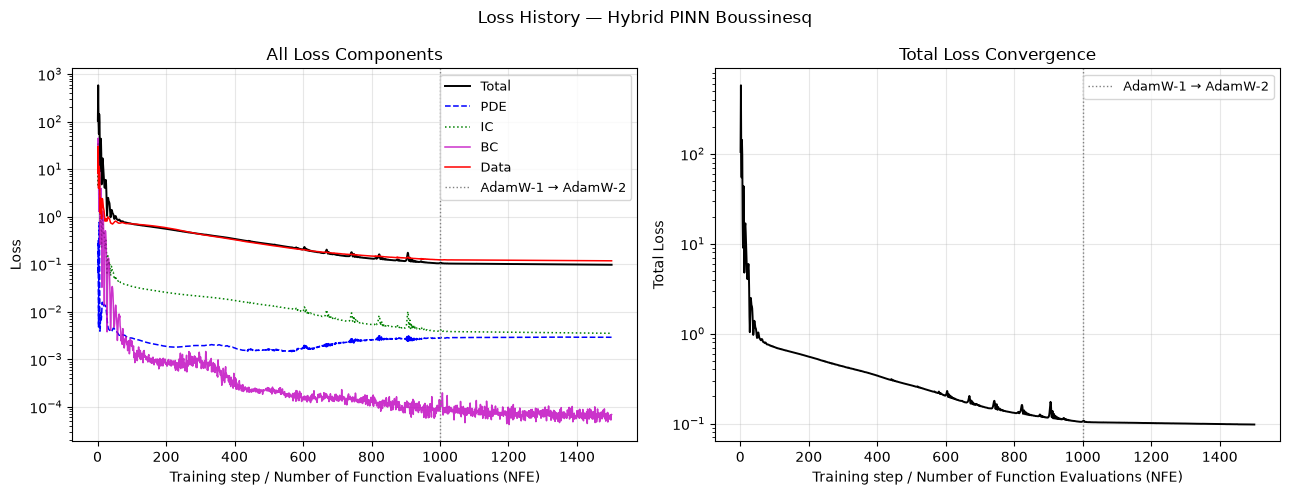

In [18]:
with open(os.path.join(BEST_DIR, "best_history.pkl"), "rb") as f:
    history = pickle.load(f)

save_path = os.path.join(fig_dir, "loss_history_BO_wetdry_adamw_adamw.png")

#Loss history
plot_loss_history(
    history,
    epochs1=1000,
    epochs2=500,
    save_path=save_path
)

  Plot disimpan: /mnt/d/PINN Research_Iwan/CodeBaru/figures/hybrid_pinn_h.png


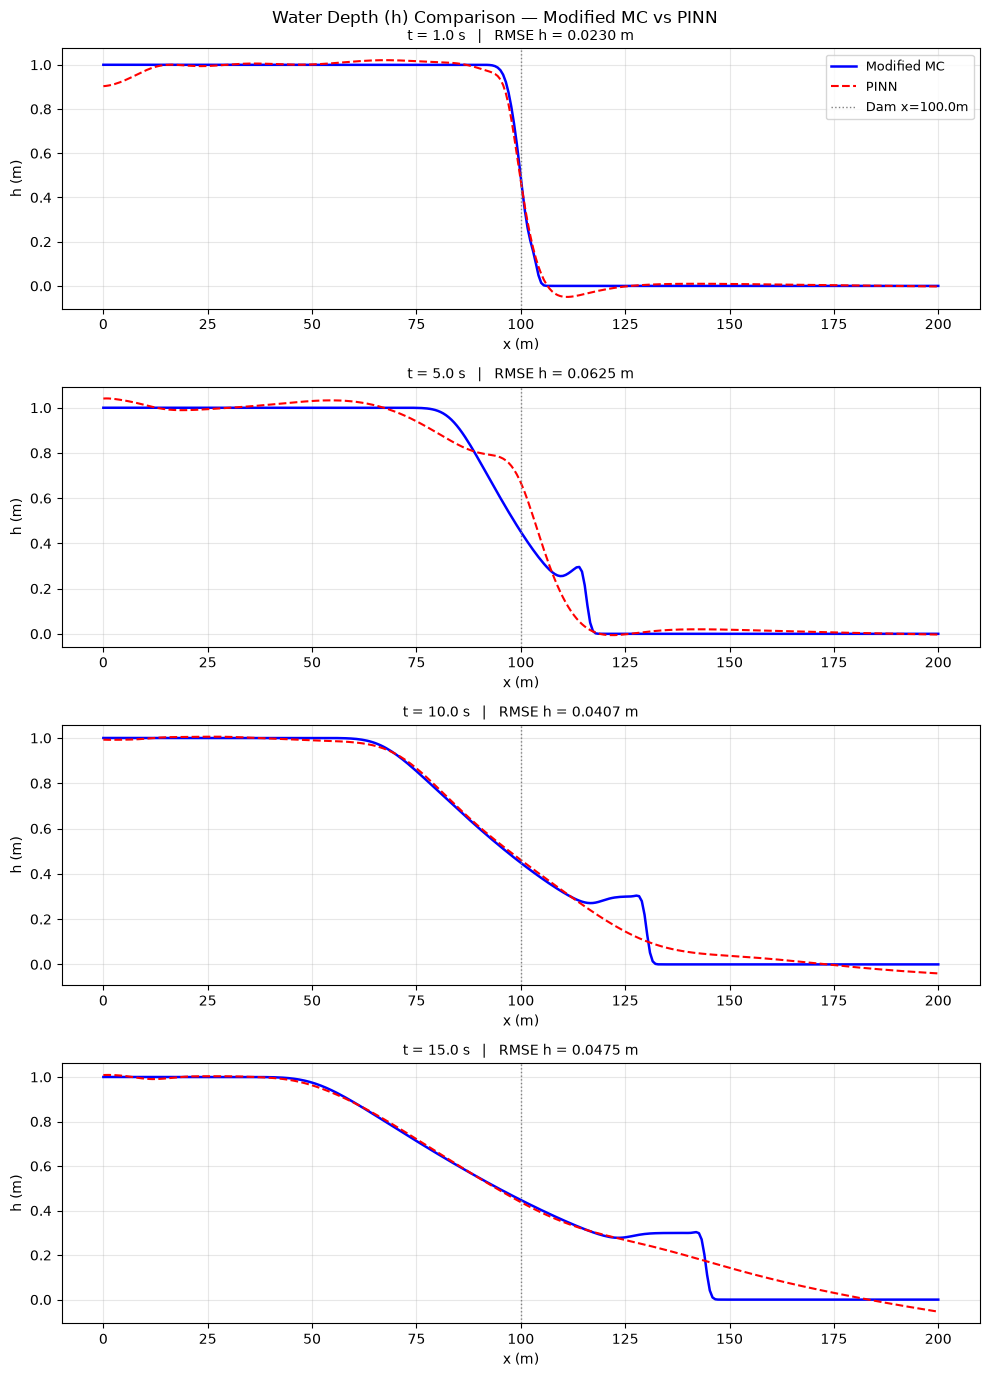

In [20]:
plot_comparison_h(
    results_mc = results_mc,
    h_model    = h_model,
    x_num      = x_num,
    times      = save_times,
    Ld         = Ld,
    save_path  = os.path.join(fig_dir, "hybrid_pinn_h.png")
)

In [12]:
def plot_comparison_u_wetdry(
    results_mc,
    u_model,
    x_num,
    times,
    Ld,
    h_tol=1e-6,
    wet_only_rmse=True,
    save_path=None
):
    """
    Perbandingan kecepatan aliran u antara Modified MC dan PINN
    untuk kasus wet-dry dam break.

    Parameters
    ----------
    results_mc : dict
        Dictionary hasil Modified MC.
        Diasumsikan:
        results_mc[t] = (h_num, u_num)

    u_model : tf.keras.Model
        Model PINN untuk prediksi velocity u.

    x_num : array-like
        Grid spasial.

    times : list or array-like
        Waktu snapshot yang ingin diplot.

    Ld : float
        Posisi dam.

    h_tol : float
        Threshold untuk menentukan daerah basah.
        Titik dianggap basah jika h_num > h_tol.

    wet_only_rmse : bool
        Jika True, RMSE u dihitung hanya pada daerah basah.
        Jika False, RMSE u dihitung pada seluruh domain.

    save_path : str or None
        Path untuk menyimpan gambar.
    """

    n = len(times)

    fig, axes = plt.subplots(n, 1, figsize=(10, 3.5 * n))

    if n == 1:
        axes = [axes]

    fig.suptitle("Flow Velocity (u) Comparison — Modified MC vs PINN")

    for i, t in enumerate(times):

        ax = axes[i]

        # ========================================================
        # Data numerik Modified MC
        # ========================================================
        if t in results_mc:
            h_num, u_num = results_mc[t]
            t_used = t
        else:
            closest = min(results_mc.keys(), key=lambda k: abs(k - t))
            h_num, u_num = results_mc[closest]
            t_used = closest
            print(f"  [peringatan] t={t} tidak tersedia, pakai t={closest}")

        # ========================================================
        # Prediksi PINN
        # ========================================================
        X_tf = tf.constant(
            np.stack(
                [
                    x_num.astype(np.float32),
                    np.full(len(x_num), t_used, dtype=np.float32)
                ],
                axis=1
            )
        )

        u_pinn = u_model(X_tf).numpy().flatten()

        # ========================================================
        # RMSE
        # ========================================================
        if wet_only_rmse:
            wet_mask = h_num > h_tol

            if np.any(wet_mask):
                rmse_u = np.sqrt(
                    np.mean((u_pinn[wet_mask] - u_num[wet_mask]) ** 2)
                )
                rmse_label = f"RMSE u wet = {rmse_u:.4f} m/s"
            else:
                rmse_u = np.nan
                rmse_label = "RMSE u wet = NaN"
                print(f"  [peringatan] Tidak ada wet cell pada t={t_used}")
        else:
            rmse_u = np.sqrt(np.mean((u_pinn - u_num) ** 2))
            rmse_label = f"RMSE u = {rmse_u:.4f} m/s"

        # ========================================================
        # Plot
        # ========================================================
        ax.plot(
            x_num,
            u_num,
            'b-',
            lw=1.8,
            label='Modified MC'
        )

        ax.plot(
            x_num,
            u_pinn,
            'r--',
            lw=1.5,
            label='PINN'
        )

        ax.axvline(
            Ld,
            color='gray',
            ls=':',
            lw=1,
            label=f'Dam x={Ld} m'
        )

        ax.set_title(
            f't = {t_used} s   |   {rmse_label}',
            fontsize=10
        )

        ax.set_xlabel('x (m)')
        ax.set_ylabel('u (m/s)')

        ax.grid(True, alpha=0.3)

        if i == 0:
            ax.legend(fontsize=9)

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches='tight'
        )
        print(f"  Plot disimpan: {save_path}")

    plt.show()

  Plot disimpan: /mnt/d/PINN Research_Iwan/CodeBaru/figures/hybrid_pinn_u.png


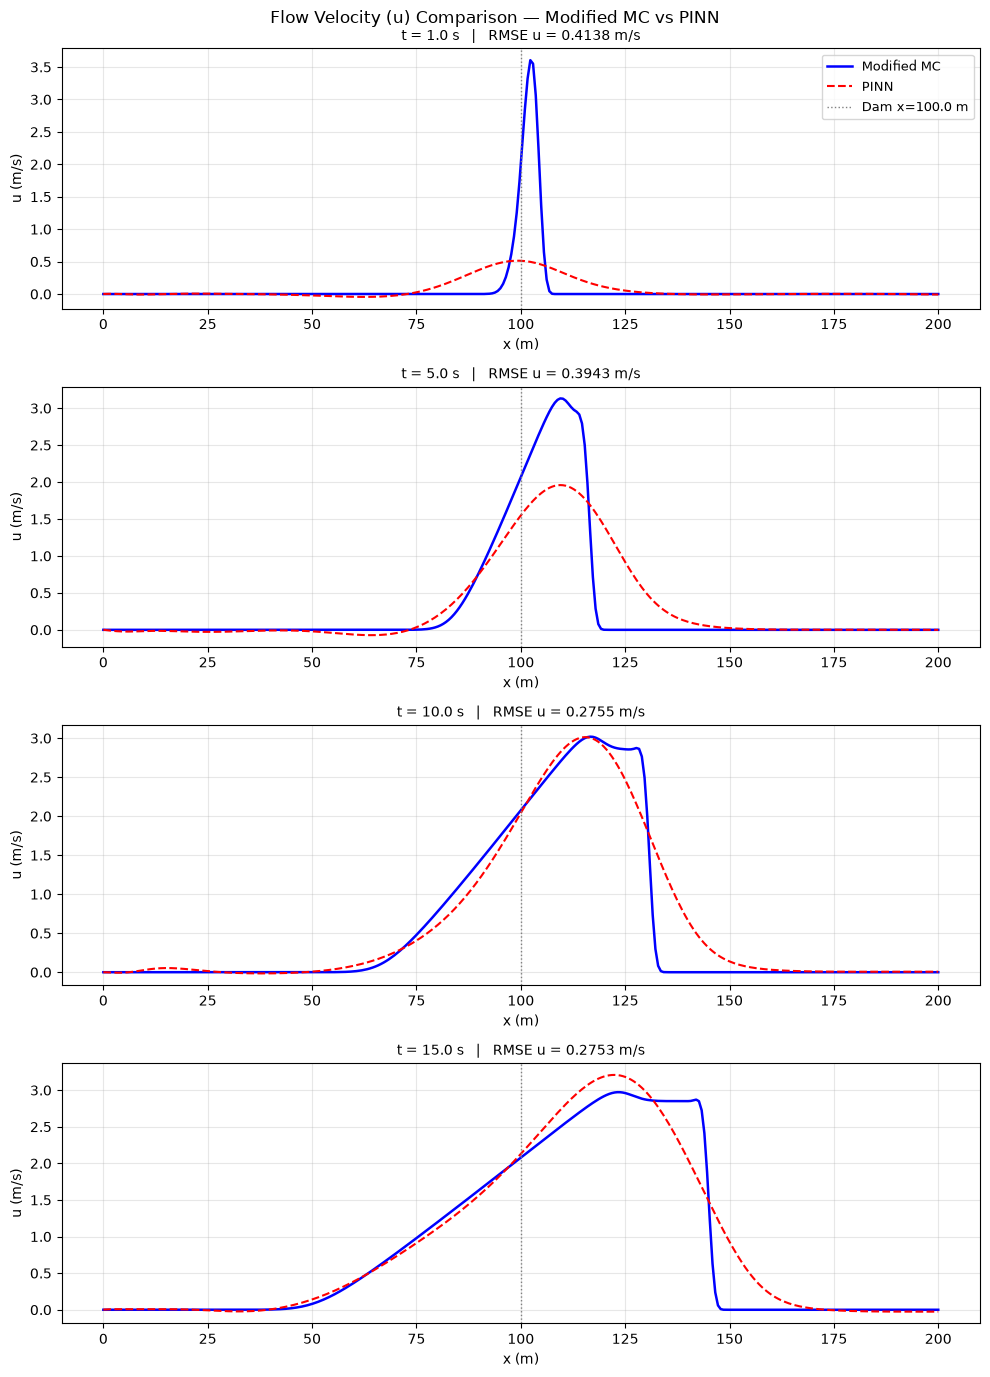

In [13]:
plot_comparison_u_wetdry(
    results_mc      = results_mc,
    u_model         = u_model,
    x_num           = x_num,
    times           = save_times,
    Ld              = Ld,
    wet_only_rmse   = False,
    save_path       = os.path.join(fig_dir, "hybrid_pinn_u.png")
)